In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving onlinebuy.csv to onlinebuy (1).csv


In [ ]:
#clean data
try:
    df = pd.read_csv('onlinebuy.csv')
    print("✅ Đã tải dữ liệu thành công. Kích thước ban đầu:", df.shape)
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file 'onlinebuy.csv'. Vui lòng kiểm tra lại tên file.")

    df = pd.read_csv('onlinebuy.csv')
if not df.empty:
    print("\n--- 5 dòng dữ liệu đầu tiên ---")
    print(df.head())
    print("\n--- Thông tin tổng quan về dữ liệu ---")
    df.info()

✅ Đã tải dữ liệu thành công. Kích thước ban đầu: (351, 38)

--- 5 dòng dữ liệu đầu tiên ---
   int1  int2  inf1  inf2  inf3  ve1  ve2  ve3  nvse1  nvse2  ...  \
0     4     3     1     1     2    2    3    3      3      3  ...   
1     2     5     4     2     3    1    1    1      2      3  ...   
2     5     5     3     5     4    2    3    4      2      2  ...   
3     5     5     3     5     3    3    3    3      2      2  ...   
4     5     5     5     5     3    1    1    2      4      3  ...   

   occupation_0  occupation_1  occupation_2  freq_0  freq_1  freq_2  freq_3  \
0             0             0             1       0       0       0       1   
1             0             0             1       0       0       0       1   
2             1             0             0       0       0       0       1   
3             1             0             0       0       0       0       1   
4             0             0             1       0       0       0       1   

   age_0  age_1  a

In [ ]:
#kiểm tra duplicate data
if not df.empty:
    print("\n##  3. Kiểm tra và Xử lý Dữ liệu Trùng lặp (Duplicate Data) ##")

    duplicate_rows_count = df.duplicated().sum()
    print(f"\nSố lượng hàng bị trùng lặp hoàn toàn: {duplicate_rows_count}")

    if duplicate_rows_count > 0:

        df_cleaned_duplicate = df.drop_duplicates(keep='first')
        df = df_cleaned_duplicate.copy()

        print(f"\n✅ Đã loại bỏ {duplicate_rows_count} hàng trùng lặp.")
        print("Kích thước dữ liệu cuối cùng sau khi làm sạch:", df.shape)
    else:
        print("\n✅ Không có hàng nào bị trùng lặp hoàn toàn.")

    print("\n--- Data Frame đã được làm sạch cuối cùng (5 dòng đầu) ---")
    print(df.head())


##  3. Kiểm tra và Xử lý Dữ liệu Trùng lặp (Duplicate Data) ##

Số lượng hàng bị trùng lặp hoàn toàn: 126

✅ Đã loại bỏ 126 hàng trùng lặp.
Kích thước dữ liệu cuối cùng sau khi làm sạch: (225, 38)

--- Data Frame đã được làm sạch cuối cùng (5 dòng đầu) ---
   int1  int2  inf1  inf2  inf3  ve1  ve2  ve3  nvse1  nvse2  ...  \
0     4     3     1     1     2    2    3    3      3      3  ...   
1     2     5     4     2     3    1    1    1      2      3  ...   
2     5     5     3     5     4    2    3    4      2      2  ...   
3     5     5     3     5     3    3    3    3      2      2  ...   
4     5     5     5     5     3    1    1    2      4      3  ...   

   occupation_0  occupation_1  occupation_2  freq_0  freq_1  freq_2  freq_3  \
0             0             0             1       0       0       0       1   
1             0             0             1       0       0       0       1   
2             1             0             0       0       0       0       1   
3          

In [ ]:
#phân tích định lượng age
print("## 1. Phân tích Biến Định lượng (Age) ##")
def create_age_group(row):
    if row['age_0'] == 1:
        return '25-34'
    elif row['age_1'] == 1:
        return '35-44'
    elif row['age_2'] == 1:
        return '45-54'
    return np.nan

df['Age_Group'] = df.apply(create_age_group, axis=1)
age_counts = df['Age_Group'].value_counts().sort_index()
age_percent = df['Age_Group'].value_counts(normalize=True).mul(100).round(2).sort_index()
age_descriptive = pd.DataFrame({'Count': age_counts, 'Percentage (%)': age_percent})

print("\n--- Thống kê Tần suất và Tỷ lệ phần trăm cho Độ tuổi ---")
print(age_descriptive)

## 1. Phân tích Biến Định lượng (Age) ##

--- Thống kê Tần suất và Tỷ lệ phần trăm cho Độ tuổi ---
           Count  Percentage (%)
Age_Group                       
25-34        170           75.56
35-44         31           13.78
45-54         24           10.67


/tmp/ipython-input-56928624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age_Group', data=df, order=age_order, palette='viridis')


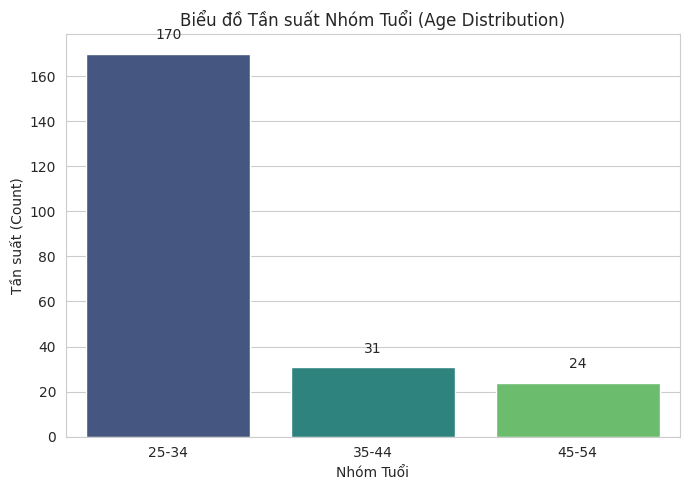

In [ ]:
#biểu đồ barchart cho age
age_order = ['25-34', '35-44', '45-54']

plt.figure(figsize=(7, 5))
sns.countplot(x='Age_Group', data=df, order=age_order, palette='viridis')
plt.title('Biểu đồ Tần suất Nhóm Tuổi (Age Distribution)')
plt.xlabel('Nhóm Tuổi')
plt.ylabel('Tần suất (Count)')

for i, count in enumerate(age_counts[age_order]):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 2. Phân tích Biến Định tính (Gender, Occupation, Frequency) ##

--- Phân tích Giới tính ---
        Count  Percentage (%)
Gender                       
Female    129           57.33
Male       96           42.67


/tmp/ipython-input-3883920025.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data=df, palette='Set1')


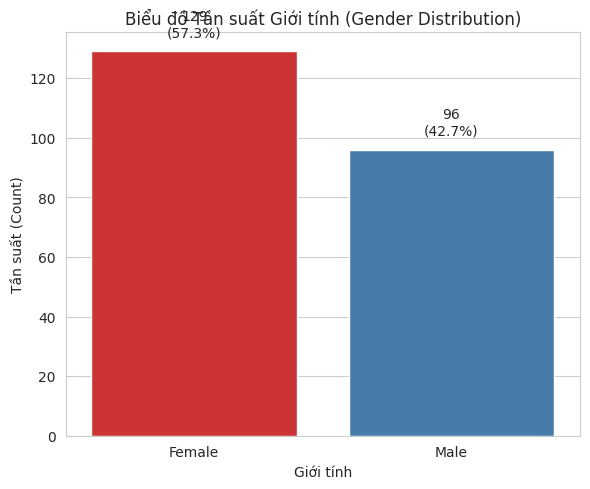

In [ ]:
#phân tích gender
print("\n## 2. Phân tích Biến Định tính (Gender, Occupation, Frequency) ##")

gender_mapping = {'gender_0': 'Female', 'gender_1': 'Male'}
df['Gender'] = df[['gender_0', 'gender_1']].idxmax(axis=1).map(gender_mapping)
gender_counts = df['Gender'].value_counts()
gender_percent = df['Gender'].value_counts(normalize=True).mul(100).round(2)
gender_descriptive = pd.DataFrame({'Count': gender_counts, 'Percentage (%)': gender_percent})
print("\n--- Phân tích Giới tính ---")
print(gender_descriptive)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Gender', data=df, palette='Set1')
plt.title('Biểu đồ Tần suất Giới tính (Gender Distribution)')
plt.xlabel('Giới tính')
plt.ylabel('Tần suất (Count)')
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5,
            f'{int(height)}\n({height/total:.1%})',
            ha="center")

plt.tight_layout()
plt.show()


--- Phân tích Nghề nghiệp ---
              Count  Percentage (%)
Occupation                         
Office Staff    126           56.00
Worker           67           29.78
Engineer         32           14.22


/tmp/ipython-input-3494575920.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Occupation', data=df, palette='Set2', order=occupation_counts.index)


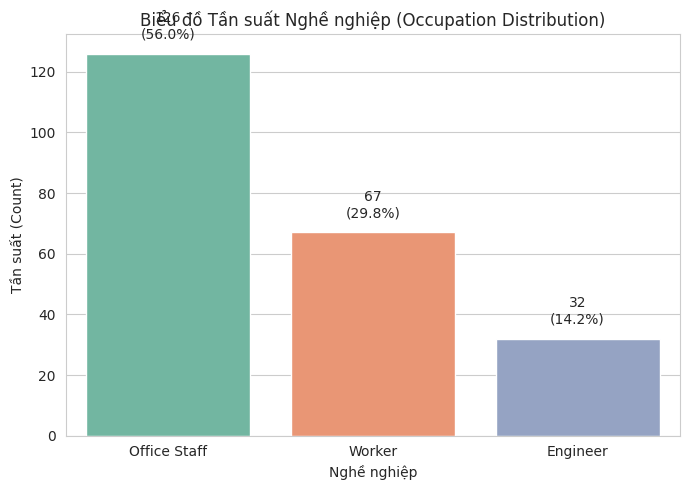

In [ ]:
#phân tích occupation
# Tái tạo biến Occupation
occupation_mapping = {'occupation_0': 'Worker', 'occupation_1': 'Engineer', 'occupation_2': 'Office Staff'}
df['Occupation'] = df[['occupation_0', 'occupation_1', 'occupation_2']].idxmax(axis=1).map(occupation_mapping)

# Tính toán Tần suất và Tỷ lệ phần trăm
occupation_counts = df['Occupation'].value_counts()
occupation_percent = df['Occupation'].value_counts(normalize=True).mul(100).round(2)
occupation_descriptive = pd.DataFrame({'Count': occupation_counts, 'Percentage (%)': occupation_percent})
print("\n--- Phân tích Nghề nghiệp ---")
print(occupation_descriptive)

# Biểu đồ Bar Chart cho Occupation
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Occupation', data=df, palette='Set2', order=occupation_counts.index)
plt.title('Biểu đồ Tần suất Nghề nghiệp (Occupation Distribution)')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Tần suất (Count)')

# Thêm giá trị tần suất và tỷ lệ phần trăm lên trên mỗi cột
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5,
            f'{int(height)}\n({height/total:.1%})',
            ha="center")

plt.tight_layout()
plt.show()


--- Phân tích Tần suất Mua sắm Online ---
           Count  Percentage (%)
Frequency                       
Monthly      129           57.33
Weekly        47           20.89
Daily         30           13.33
Seldom        19            8.44


/tmp/ipython-input-273930341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Frequency', data=df, palette='Set3', order=freq_counts.index)


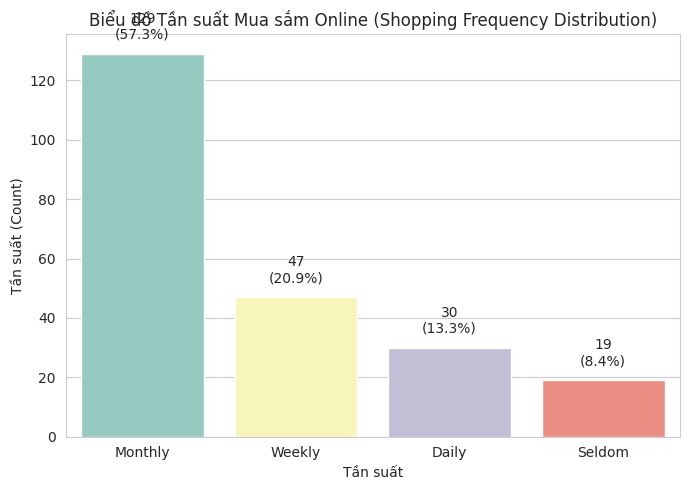

In [ ]:
#Phân tích Shopping Frequency
# Tái tạo biến Shopping Frequency
freq_mapping = {'freq_0': 'Daily', 'freq_1': 'Weekly', 'freq_2': 'Seldom', 'freq_3': 'Monthly'}
df['Frequency'] = df[['freq_0', 'freq_1', 'freq_2', 'freq_3']].idxmax(axis=1).map(freq_mapping)
freq_counts = df['Frequency'].value_counts()
freq_percent = df['Frequency'].value_counts(normalize=True).mul(100).round(2)
freq_descriptive = pd.DataFrame({'Count': freq_counts, 'Percentage (%)': freq_percent})
print("\n--- Phân tích Tần suất Mua sắm Online ---")
print(freq_descriptive)

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Frequency', data=df, palette='Set3', order=freq_counts.index)
plt.title('Biểu đồ Tần suất Mua sắm Online (Shopping Frequency Distribution)')
plt.xlabel('Tần suất')
plt.ylabel('Tần suất (Count)')
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5,
            f'{int(height)}\n({height/total:.1%})',
            ha="center")

plt.tight_layout()
plt.show()

## Đọc file onlinebuy.csv ##
Shape dữ liệu: (351, 38)
   int1  int2  inf1  inf2  inf3  ve1  ve2  ve3  nvse1  nvse2  ...  \
0     4     3     1     1     2    2    3    3      3      3  ...   
1     2     5     4     2     3    1    1    1      2      3  ...   
2     5     5     3     5     4    2    3    4      2      2  ...   
3     5     5     3     5     3    3    3    3      2      2  ...   
4     5     5     5     5     3    1    1    2      4      3  ...   

   occupation_0  occupation_1  occupation_2  freq_0  freq_1  freq_2  freq_3  \
0             0             0             1       0       0       0       1   
1             0             0             1       0       0       0       1   
2             1             0             0       0       0       0       1   
3             1             0             0       0       0       0       1   
4             0             0             1       0       0       0       1   

   age_0  age_1  age_2  
0      0      0      1  
1     

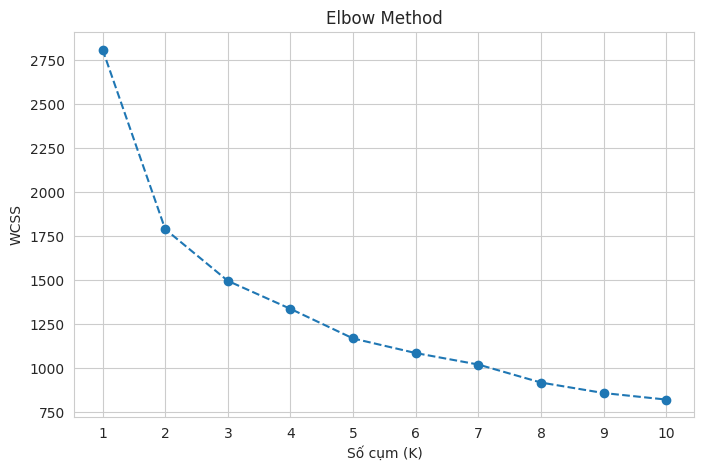


## 3. Chạy K-Means với K= 3 ##
Số mẫu trong mỗi cụm:
Cluster
1    140
0    133
2     78
Name: count, dtype: int64

## 4. Cluster Profiles ##
              INT       INF        VE      NVSE     TRUST      CONV       ENJ  \
Cluster                                                                         
0        4.593985  3.756892  2.446115  1.827068  3.395990  4.152256  4.080201   
1        3.114286  3.119048  2.569048  2.978571  2.871429  3.392857  3.414286   
2        4.641026  3.974359  1.623932  1.467949  4.307692  4.766026  4.970085   

               SC        AL  
Cluster                      
0        3.744361  2.150376  
1        3.360714  2.676190  
2        3.589744  1.294872  

## 5. Radar Chart ##


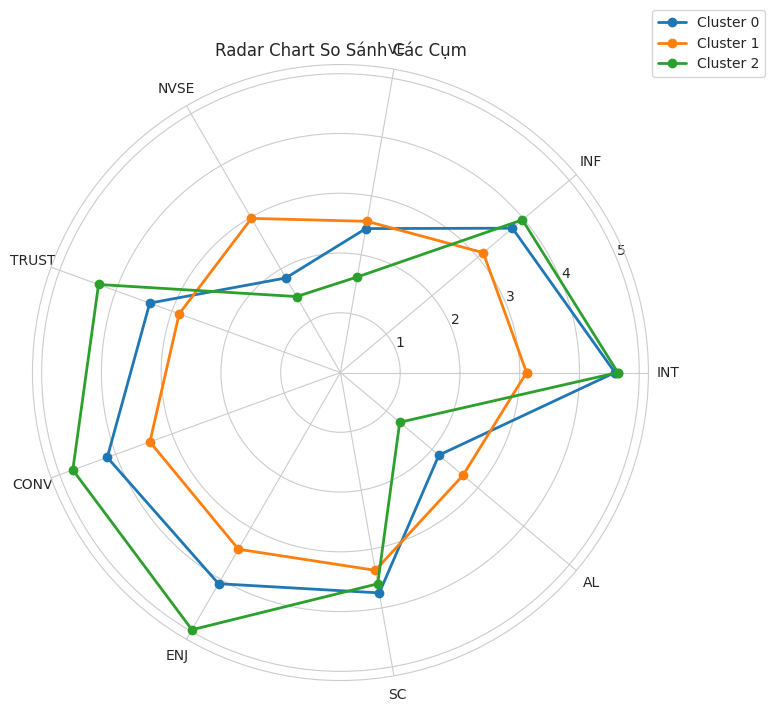


## 6. 5 dòng đầu với nhãn cụm ##
   INT       INF        VE  NVSE     TRUST  CONV       ENJ   SC        AL  \
0  3.5  1.333333  2.666667   3.0  2.666667  3.50  3.000000  4.0  3.000000   
1  3.5  3.000000  1.000000   2.5  4.666667  5.00  5.000000  3.0  1.000000   
2  5.0  4.000000  3.000000   2.0  3.333333  4.25  4.333333  4.5  2.333333   
3  5.0  3.666667  3.000000   2.0  3.666667  4.25  3.000000  2.0  2.333333   
4  5.0  4.333333  1.333333   3.5  4.666667  4.00  3.333333  5.0  1.000000   

   Cluster  
0        1  
1        2  
2        0  
3        0  
4        0  


In [ ]:
#Cluster
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập hiển thị
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# --- 0. Đọc dữ liệu ---
print("## Đọc file onlinebuy.csv ##")
df = pd.read_csv("onlinebuy.csv")
print("Shape dữ liệu:", df.shape)
print(df.head())

# --- 1. Chuẩn bị Dữ liệu: Tính Mean Scores ---
print("\n## 1. Tính Mean Score cho từng Construct ##")

factors_for_clustering = {
    'INT': ['int1', 'int2'],
    'INF': ['inf1', 'inf2', 'inf3'],
    'VE': ['ve1', 've2', 've3'],
    'NVSE': ['nvse1', 'nvse2'],
    'TRUST': ['trust1', 'trust2', 'trust3'],
    'CONV': ['conv1', 'conv2', 'conv3', 'conv4'],
    'ENJ': ['enj1', 'enj2', 'enj3'],
    'SC': ['sc1', 'sc2']
}

# Tạo dataframe chứa Mean của từng construct
df_clustering_input = pd.DataFrame()
for name, cols in factors_for_clustering.items():
    df_clustering_input[name] = df[cols].mean(axis=1)

# Mean của Attitudinal Loyalty — dùng để phân tích profile
df_clustering_input['AL'] = df[['al1', 'al2', 'al3']].mean(axis=1)

print("Dữ liệu Input Clustering:", df_clustering_input.shape)
print(df_clustering_input.head())

# --- 2. Chuẩn hóa dữ liệu ---
print("\n## 2. Chuẩn hóa dữ liệu ##")

input_cols = list(factors_for_clustering.keys())
X = df_clustering_input[input_cols]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(df_scaled, columns=input_cols)

print(df_scaled.head())

# --- 3. Elbow Method chọn số cụm ---
print("\n## Elbow Method để xác định K ##")

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method")
plt.xlabel("Số cụm (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

# --- 4. Chạy mô hình K-Means ---
K_OPTIMAL = 3  # Bạn có thể đổi theo Elbow Chart

print("\n## 3. Chạy K-Means với K=", K_OPTIMAL, "##")

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df_clustering_input['Cluster'] = clusters
df_scaled['Cluster'] = clusters

print("Số mẫu trong mỗi cụm:")
print(df_clustering_input['Cluster'].value_counts())

# --- 5. Tính trung bình theo cụm ---
print("\n## 4. Cluster Profiles ##")

cluster_profile = df_clustering_input.groupby("Cluster")[input_cols + ['AL']].mean()
print(cluster_profile)

# --- 6. Radar Chart ---
print("\n## 5. Radar Chart ##")

def plot_radar(cluster_profile):
    labels = cluster_profile.columns.tolist()
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8,8))

    for cluster in cluster_profile.index:
        values = cluster_profile.loc[cluster].tolist()
        values += values[:1]

        plt.polar(angles, values, marker='o', linewidth=2, label=f"Cluster {cluster}")

    plt.xticks(angles[:-1], labels, fontsize=10)
    plt.title("Radar Chart So Sánh Các Cụm")
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.show()

plot_radar(cluster_profile)

# --- 7. Hiển thị kết quả ---
print("\n## 6. 5 dòng đầu với nhãn cụm ##")
print(df_clustering_input.head())


In [ ]:
#phân tích profile cụm
# --- 4. Thực hiện K-Means Clustering (Chọn K=3) ---
print(f"\n## 3. Thực hiện K-Means và Phân tích Profile Cụm (K={K_OPTIMAL}) ##")

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Gán nhãn cụm vào Data Frame Input ban đầu (có cả AL)
df_clustering_input['Cluster'] = cluster_labels

print(f"\n✅ Đã thực hiện K-Means Clustering với K = {K_OPTIMAL} cụm.")
print("Tần suất các Cụm:")
cluster_counts = df_clustering_input['Cluster'].value_counts().sort_index()
print(pd.DataFrame({'Count': cluster_counts, 'Percentage (%)': cluster_counts/len(df_clustering_input) * 100}).round(2))

# --- 5. Phân tích Profile Cụm ---
cluster_profile = df_clustering_input.groupby('Cluster').mean().round(3)

# Sắp xếp các cụm dựa trên biến AL (Loyalty) để đặt tên cụm hợp lý
cluster_profile = cluster_profile.sort_values(by='AL', ascending=False)
print("\nBảng Profile Cụm (Mean Scores, Sắp xếp theo AL giảm dần):")
print(cluster_profile)


## 3. Thực hiện K-Means và Phân tích Profile Cụm (K=3) ##

✅ Đã thực hiện K-Means Clustering với K = 3 cụm.
Tần suất các Cụm:
         Count  Percentage (%)
Cluster                       
0           78           22.22
1          140           39.89
2          133           37.89

Bảng Profile Cụm (Mean Scores, Sắp xếp theo AL giảm dần):
           INT    INF     VE   NVSE  TRUST   CONV    ENJ     SC     AL
Cluster                                                               
1        3.114  3.119  2.569  2.979  2.871  3.393  3.414  3.361  2.676
2        4.594  3.757  2.446  1.827  3.396  4.152  4.080  3.744  2.150
0        4.641  3.974  1.624  1.468  4.308  4.766  4.970  3.590  1.295


## 1. Scatter Plot: Platform Features vs. Attitudinal Loyalty (AL) ##


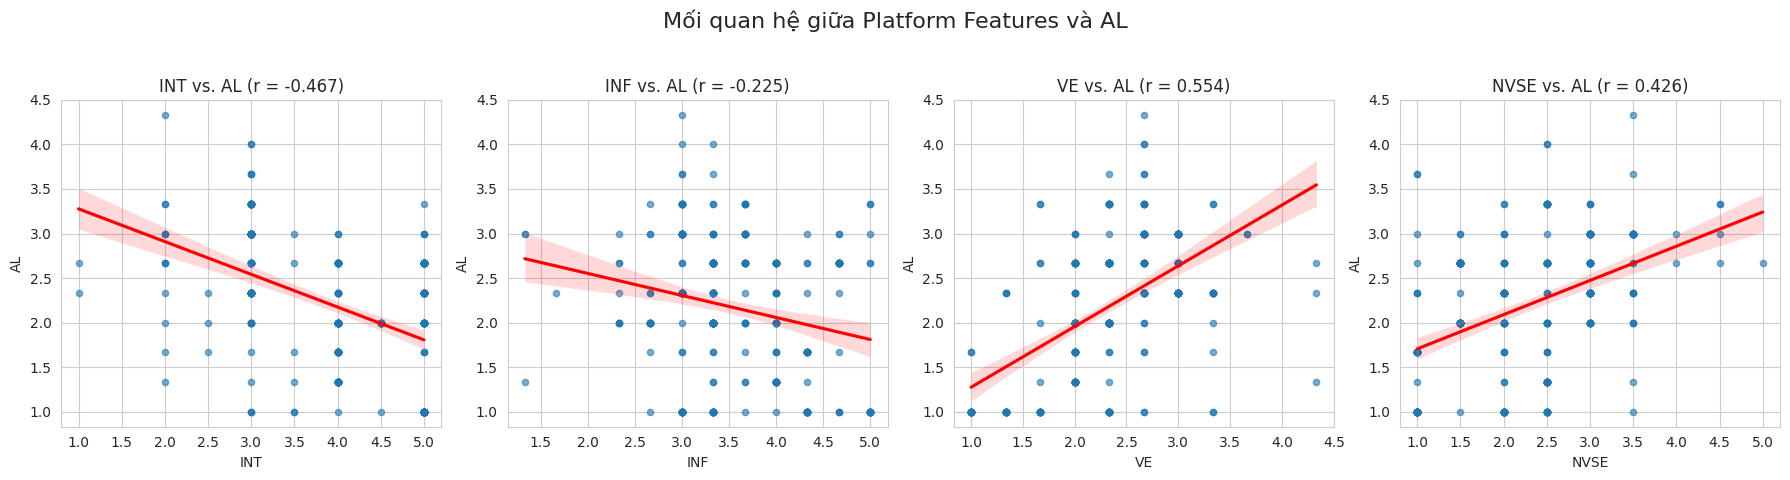


## 2. Scatter Plot: Psychological Responses vs. Attitudinal Loyalty (AL) ##


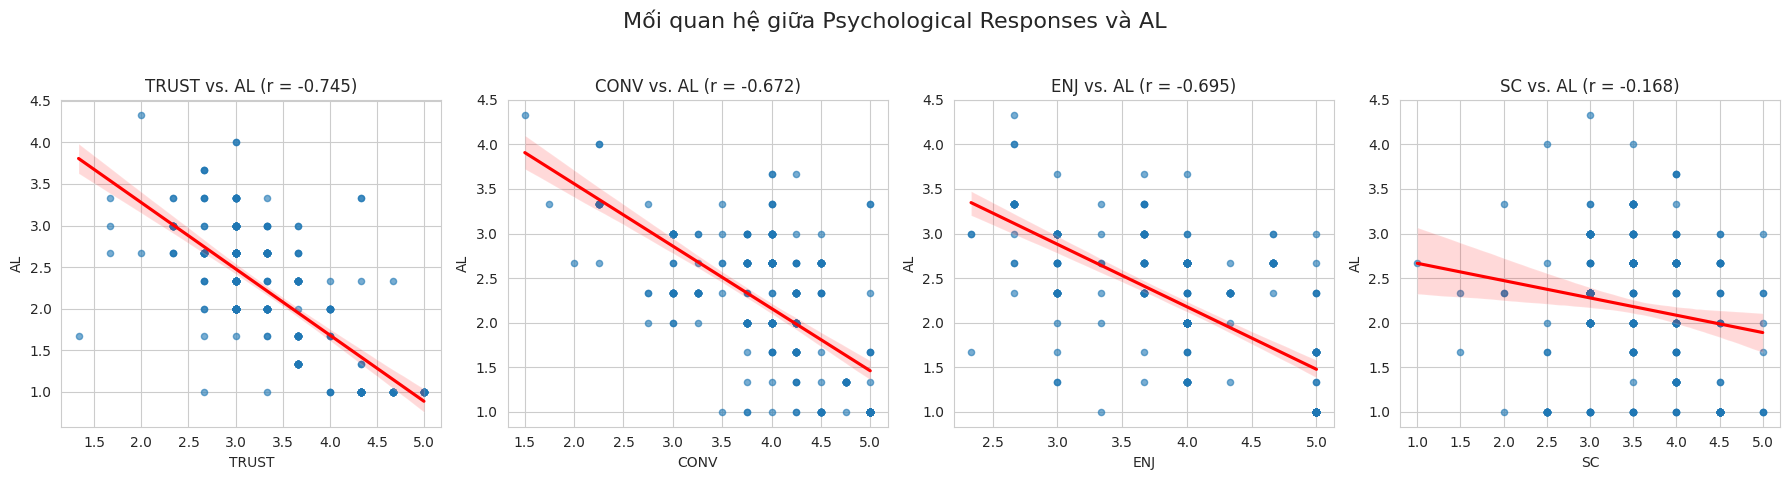

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập chế độ hiển thị cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# Giả sử df_clustering_input đã được tạo từ bước Cluster Analysis trước
# df_clustering_input chứa Mean Scores (INT, INF, VE, NVSE, TRUST, CONV, ENJ, SC, AL)

# Biến phụ thuộc (Y)
Y = 'AL'

# --- 1. Mối quan hệ giữa Platform Features và Attitudinal Loyalty (AL) ---
platform_features = ['INT', 'INF', 'VE', 'NVSE']

print("## 1. Scatter Plot: Platform Features vs. Attitudinal Loyalty (AL) ##")

# Tạo subplots để hiển thị nhiều biểu đồ trong cùng một hình
fig, axes = plt.subplots(1, len(platform_features), figsize=(18, 5))
fig.suptitle(f'Mối quan hệ giữa Platform Features và {Y}', fontsize=16)

for i, X in enumerate(platform_features):
    # Sử dụng regplot để vẽ Scatter Plot và đường hồi quy tuyến tính (Linear Regression Line)
    sns.regplot(x=X, y=Y, data=df_clustering_input, ax=axes[i], scatter_kws={'alpha':0.6, 's':20}, line_kws={'color':'red'})

    # Tính toán hệ số tương quan Pearson
    correlation = df_clustering_input[[X, Y]].corr().iloc[0, 1].round(3)

    axes[i].set_title(f'{X} vs. {Y} (r = {correlation})')
    axes[i].set_xlabel(X)
    axes[i].set_ylabel(Y)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Điều chỉnh layout để không bị đè bởi suptitle
plt.show()

# --- 2. Mối quan hệ giữa Psychological Responses và Attitudinal Loyalty (AL) ---
psychological_responses = ['TRUST', 'CONV', 'ENJ', 'SC']

print("\n## 2. Scatter Plot: Psychological Responses vs. Attitudinal Loyalty (AL) ##")

# Tạo subplots
fig, axes = plt.subplots(1, len(psychological_responses), figsize=(18, 5))
fig.suptitle(f'Mối quan hệ giữa Psychological Responses và {Y}', fontsize=16)

for i, X in enumerate(psychological_responses):
    # Sử dụng regplot để vẽ Scatter Plot và đường hồi quy tuyến tính
    sns.regplot(x=X, y=Y, data=df_clustering_input, ax=axes[i], scatter_kws={'alpha':0.6, 's':20}, line_kws={'color':'red'})

    # Tính toán hệ số tương quan Pearson
    correlation = df_clustering_input[[X, Y]].corr().iloc[0, 1].round(3)

    axes[i].set_title(f'{X} vs. {Y} (r = {correlation})')
    axes[i].set_xlabel(X)
    axes[i].set_ylabel(Y)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
!pip install factor_analyzer --quiet

In [ ]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Giả định df là Data Frame đã được làm sạch từ bước trước

# --- 1. Chuẩn bị Dữ liệu EFA ---
print("## 1. Chuẩn bị Dữ liệu và Kiểm tra Phù hợp ##")

# Các biến đo lường (từ int1 đến al3)
measurement_vars = [col for col in df.columns if col.startswith(('int', 'inf', 've', 'nvse', 'trust', 'conv', 'enj', 'sc', 'al'))]
df_efa = df[measurement_vars].copy()

# Kiểm tra 5 dòng đầu
print("Data Frame Input EFA (5 dòng đầu):")
print(df_efa.head())

# --- 2. Kiểm tra Phù hợp Dữ liệu cho EFA ---

# 2.1. Kiểm tra KMO (Kaiser-Meyer-Olkin) - Đánh giá mức độ phù hợp của dữ liệu cho EFA
# KMO > 0.6 là chấp nhận được, > 0.7 là tốt
kmo_all, kmo_model = calculate_kmo(df_efa)
print(f"\nKMO Test (Overall): {kmo_model:.4f}")

# 2.2. Kiểm tra Bartlett's Sphericity Test - Kiểm tra ma trận tương quan có phải là ma trận đơn vị không
# P-value < 0.05 (significance) cho thấy ma trận tương quan có ý nghĩa và phù hợp để phân tích nhân tố.
chi_square_value, p_value = calculate_bartlett_sphericity(df_efa)
print(f"Bartlett's Test (Chi-Square): {chi_square_value:.2f}")
print(f"Bartlett's Test (P-value): {p_value:.4f}")

if kmo_model > 0.6 and p_value < 0.05:
    print("✅ Dữ liệu phù hợp để tiến hành EFA.")
else:
    print("❌ Dữ liệu không phù hợp cho EFA. Cần xem xét lại.")

## 1. Chuẩn bị Dữ liệu và Kiểm tra Phù hợp ##
Data Frame Input EFA (5 dòng đầu):
   int1  int2  inf1  inf2  inf3  ve1  ve2  ve3  nvse1  nvse2  ...  conv3  \
0     4     3     1     1     2    2    3    3      3      3  ...      4   
1     2     5     4     2     3    1    1    1      2      3  ...      5   
2     5     5     3     5     4    2    3    4      2      2  ...      3   
3     5     5     3     5     3    3    3    3      2      2  ...      3   
4     5     5     5     5     3    1    1    2      4      3  ...      5   

   conv4  enj1  enj2  enj3  sc1  sc2  al1  al2  al3  
0      5     4     4     1    4    4    3    3    3  
1      5     5     5     5    3    3    1    1    1  
2      4     3     5     5    5    4    2    3    2  
3      4     3     2     4    2    2    2    3    2  
4      1     2     4     4    5    5    1    1    1  

[5 rows x 25 columns]

KMO Test (Overall): 0.8557
Bartlett's Test (Chi-Square): 5509.72
Bartlett's Test (P-value): 0.0000
✅ Dữ liệu phù h

/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(



## 2. Xác định Số lượng Nhân tố Tối ưu (Scree Plot) ##


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


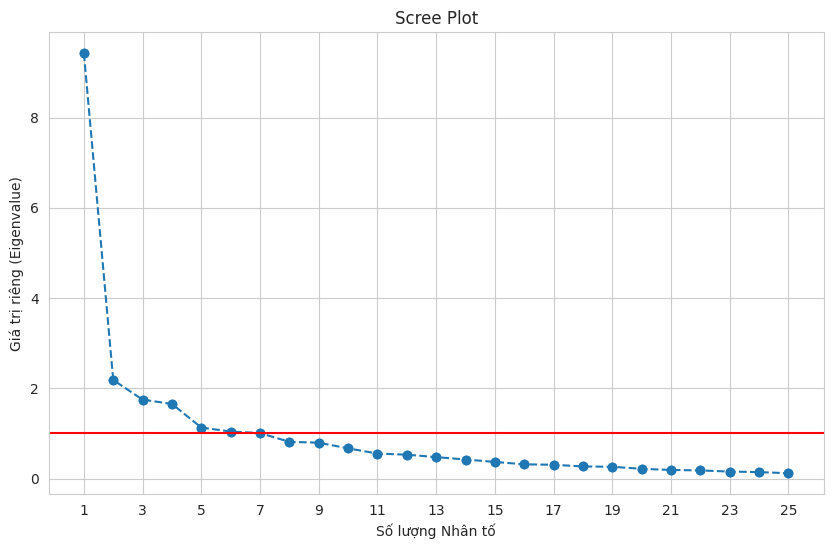


Giá trị riêng (Eigenvalues):
Factor 1: 9.424 (Sẽ được trích)
Factor 2: 2.184 (Sẽ được trích)
Factor 3: 1.750 (Sẽ được trích)
Factor 4: 1.655 (Sẽ được trích)
Factor 5: 1.131 (Sẽ được trích)
Factor 6: 1.043 (Sẽ được trích)
Factor 7: 1.010 (Sẽ được trích)
Factor 8: 0.814
Factor 9: 0.796
Factor 10: 0.670
Factor 11: 0.555
Factor 12: 0.530
Factor 13: 0.477
Factor 14: 0.423
Factor 15: 0.370
Factor 16: 0.317
Factor 17: 0.307
Factor 18: 0.269
Factor 19: 0.262
Factor 20: 0.217
Factor 21: 0.192
Factor 22: 0.181
Factor 23: 0.157
Factor 24: 0.145
Factor 25: 0.120

=> Chọn 9 Nhân tố để trích.


In [ ]:
# --- 3. Xác định Số lượng Nhân tố (Factors) ---
print("\n## 2. Xác định Số lượng Nhân tố Tối ưu (Scree Plot) ##")

# Chạy Factor Analysis ban đầu để lấy Eigenvalues
fa = FactorAnalyzer(n_factors=df_efa.shape[1], rotation=None) # n_factors = số lượng biến
fa.fit(df_efa)
eigen_values = fa.get_eigenvalues()[0]

# Tạo Scree Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, df_efa.shape[1] + 1), eigen_values)
plt.plot(range(1, df_efa.shape[1] + 1), eigen_values, marker='o', linestyle='--')
plt.axhline(y=1, color='r', linestyle='-') # Đường ngưỡng Eigenvalue > 1
plt.title('Scree Plot')
plt.xlabel('Số lượng Nhân tố')
plt.ylabel('Giá trị riêng (Eigenvalue)')
plt.grid(True)
plt.xticks(range(1, df_efa.shape[1] + 1, 2))
plt.show()

print("\nGiá trị riêng (Eigenvalues):")
for i, ev in enumerate(eigen_values):
    if ev >= 1:
        print(f"Factor {i+1}: {ev:.3f} (Sẽ được trích)")
    else:
        print(f"Factor {i+1}: {ev:.3f}")

# Dựa trên tiêu chí Eigenvalue > 1 và Scree Plot, giả sử chúng ta chọn K=9 nhân tố
# (hoặc K=8 nếu loại bỏ AL, tùy vào cách mô hình nghiên cứu của bạn)
# Ta thấy có 9 giá trị Eigenvalue lớn hơn 1.
K_FACTORS = 9
print(f"\n=> Chọn {K_FACTORS} Nhân tố để trích.")

In [ ]:
# --- 4. Thực hiện EFA và Phân tích Ma trận Tải (Factor Loadings) ---
print(f"\n## 3. Thực hiện EFA ({K_FACTORS} Factors) và Phân tích Ma trận Tải ##")

# Chạy Factor Analysis với số nhân tố đã chọn và phép quay Varimax
fa_final = FactorAnalyzer(n_factors=K_FACTORS, rotation='varimax', method='ml') # Sử dụng Maximum Likelihood
fa_final.fit(df_efa)

# Lấy ma trận Factor Loadings
loadings = pd.DataFrame(fa_final.loadings_, index=df_efa.columns)
loadings.columns = [f'Factor_{i+1}' for i in range(K_FACTORS)]

# Định dạng hiển thị: Chỉ giữ lại các giá trị tải (loading) > 0.4
# (Đánh dấu các giá trị tải mạnh để dễ dàng nhóm biến)
loadings_formatted = loadings.applymap(lambda x: f"{x:.3f}" if abs(x) >= 0.4 else "")

print("\nMa trận Factor Loadings (Chỉ hiển thị giá trị tải > 0.4):")
# Hiển thị tất cả các cột
pd.set_option('display.max_columns', None)
print(loadings_formatted)
pd.reset_option('display.max_columns') # Đặt lại tùy chọn

# Tính toán phương sai được giải thích (Explained Variance)
explained_variance = fa_final.get_factor_variance()
explained_variance_df = pd.DataFrame({
    'Variance': explained_variance[0].round(4),
    'Proportional Variance': explained_variance[1].round(4),
    'Cumulative Variance': explained_variance[2].round(4)
}, index=[f'Factor_{i+1}' for i in range(K_FACTORS)])

print("\nPhương sai được giải thích bởi mỗi Nhân tố:")
print(explained_variance_df)

print(f"\nTổng phương sai tích lũy được giải thích: {explained_variance_df['Cumulative Variance'].iloc[-1]*100:.2f}%")


## 3. Thực hiện EFA (9 Factors) và Phân tích Ma trận Tải ##


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Ma trận Factor Loadings (Chỉ hiển thị giá trị tải > 0.4):
       Factor_1 Factor_2 Factor_3 Factor_4 Factor_5 Factor_6 Factor_7  \
int1      0.562                                                         
int2      0.750                                                         
inf1                                 0.533                              
inf2                                 0.770                              
inf3                                 0.734                              
ve1                        -0.410                                       
ve2                        -0.466             0.542                     
ve3                                           0.890                     
nvse1    -0.681                                                         
nvse2    -0.425                                                         
trust1    0.425                                                 0.581   
trust2             0.526                                        0

/tmp/ipython-input-3415388604.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  loadings_formatted = loadings.applymap(lambda x: f"{x:.3f}" if abs(x) >= 0.4 else "")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('onlinebuy.csv')
    print("✅ Đã tải tệp 'onlinebuy.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy tệp 'onlinebuy.csv'. Vui lòng kiểm tra lại đường dẫn.")
    exit() # Dừng chương trình nếu không tìm thấy tệp
# ----------------------------------------------------

measurement_vars = [
    # Interactivity (int), Informativeness (inf), Visual Engagement (ve)
    'int1', 'int2', 'inf1', 'inf2', 'inf3', 've1', 've2', 've3',
    # Ease of Navigation (nvse)
    'nvse1', 'nvse2',
    # Trust (trust), Convenience (conv), Enjoyment (enj), Self-Control (sc)
    'trust1', 'trust2', 'trust3', 'conv1', 'conv2', 'conv3', 'conv4',
    'enj1', 'enj2', 'enj3', 'sc1', 'sc2',
    # al1, al2, al3 (Nếu các biến này cũng thuộc các khái niệm chính)
    'al1', 'al2', 'al3'
]


print("\n## 1. Tính Ma trận Tương quan Pearson ##")

# Chọn các cột cần phân tích (Bây giờ tên cột đã khớp)
df_corr = df[measurement_vars].copy()

# Tính toán ma trận tương quan (Phương pháp mặc định là Pearson)
correlation_matrix = df_corr.corr(method='pearson')

# In ma trận ra màn hình
print(correlation_matrix)

✅ Đã tải tệp 'onlinebuy.csv' thành công.

## 1. Tính Ma trận Tương quan Pearson ##
            int1      int2      inf1      inf2      inf3       ve1       ve2  \
int1    1.000000  0.553314  0.267249  0.319285  0.085828 -0.411301 -0.285211   
int2    0.553314  1.000000  0.281316  0.273438  0.003170 -0.234933 -0.254565   
inf1    0.267249  0.281316  1.000000  0.562001  0.399215 -0.262872 -0.342429   
inf2    0.319285  0.273438  0.562001  1.000000  0.550643 -0.328522 -0.413629   
inf3    0.085828  0.003170  0.399215  0.550643  1.000000 -0.161405 -0.253831   
ve1    -0.411301 -0.234933 -0.262872 -0.328522 -0.161405  1.000000  0.564586   
ve2    -0.285211 -0.254565 -0.342429 -0.413629 -0.253831  0.564586  1.000000   
ve3     0.018939 -0.095669  0.043160 -0.003386  0.093064  0.356086  0.516772   
nvse1  -0.532393 -0.625008 -0.342972 -0.330167 -0.108375  0.407914  0.368339   
nvse2  -0.371936 -0.483908 -0.033722 -0.246798 -0.031854  0.186725  0.178947   
trust1  0.443644  0.432678  0.293901 


## 2. Trực quan hóa Ma trận Tương quan bằng Heatmap ##


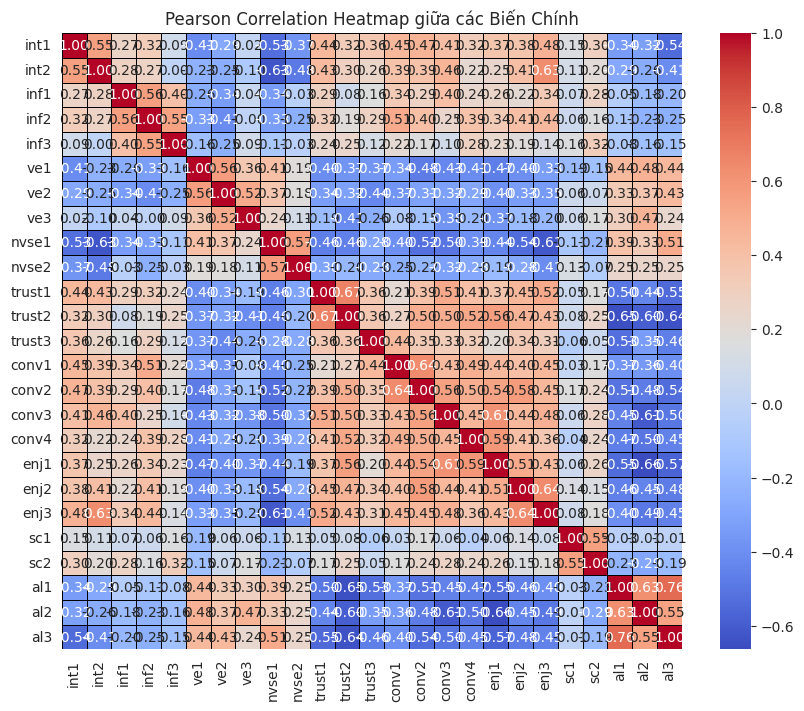

In [ ]:
print("\n## 2. Trực quan hóa Ma trận Tương quan bằng Heatmap ##")

plt.figure(figsize=(10, 8))

# Vẽ Heatmap
# 'annot=True' hiển thị giá trị tương quan trên ô
# 'cmap' là bảng màu (ví dụ: 'coolwarm' thể hiện rõ tương quan dương và âm)
# 'fmt=".2f"' định dạng giá trị số
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            linecolor='black',
            cbar=True)

plt.title('Pearson Correlation Heatmap giữa các Biến Chính')
plt.show()

✅ Đã tải tệp 'onlinebuy.csv' thành công.

## 2.1 Ma trận Tương quan giữa các Biến Độc lập (Platform Features) ##


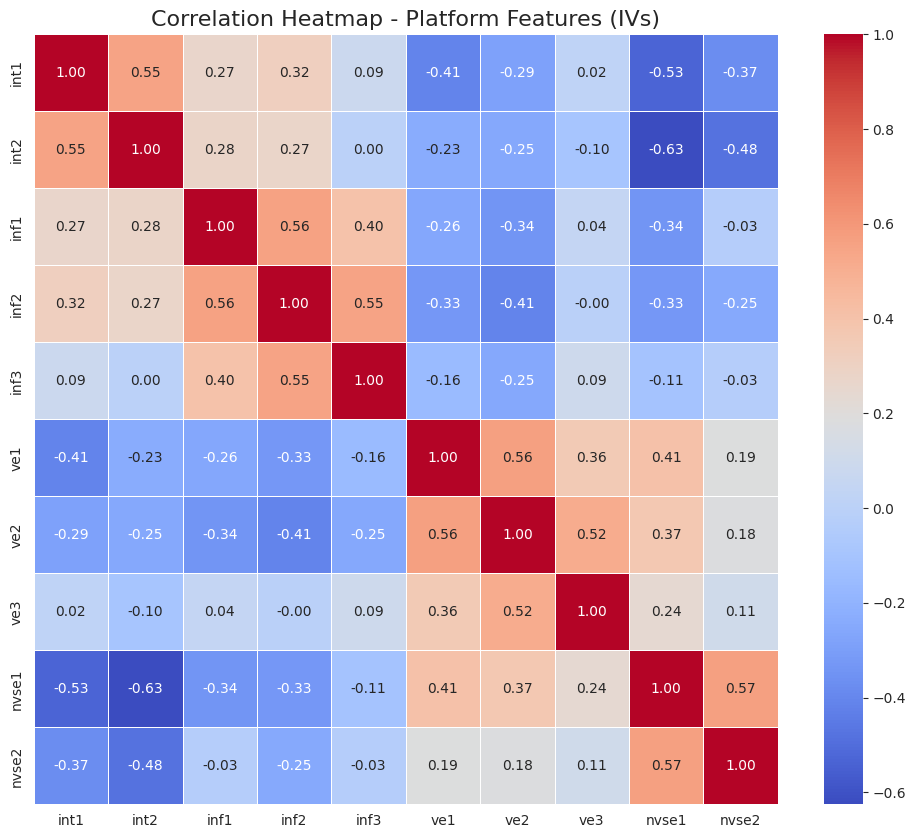


## 2.2 Tính VIF (Variance Inflation Factor) ##
  feature      VIF
3    inf2  38.7016
2    inf1  33.8480
4    inf3  28.7877
1    int2  25.2114
7     ve3  24.1114
0    int1  23.2014
6     ve2  19.2241
5     ve1  12.8537
8   nvse1  12.5804
9   nvse2  11.2543

## 2.3 Tính Chỉ số Điều kiện (Condition Index) ##
Condition Index (sqrt(Max Eig / Min Eig)): 3.8046


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from numpy.linalg import eigvals

# --- 1. Tải và Chuẩn bị Dữ liệu ---
try:
    # Đọc tệp dữ liệu đã tải lên
    df = pd.read_csv('onlinebuy.csv')
    print("✅ Đã tải tệp 'onlinebuy.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy tệp 'onlinebuy.csv'. Vui lòng kiểm tra lại tên tệp.")
    exit()

# Định nghĩa các biến theo câu hỏi nghiên cứu
# Biến Độc lập (IVs): Platform Features
platform_features_vars = [
    'int1', 'int2',         # Interactivity
    'inf1', 'inf2', 'inf3', # Informativeness
    've1', 've2', 've3',    # Visual Engagement
    'nvse1', 'nvse2'        # Ease of Navigation
]

# Biến Phụ thuộc (DVs): Attitudinal Loyalty
attitudinal_loyalty_vars = ['al1', 'al2', 'al3']

# Tạo DataFrame chỉ chứa các Biến Độc lập (IVs) cho phân tích đa cộng tuyến (Multicollinearity)
multi_c_df = df[platform_features_vars].copy()

# --- 2. Phân tích Đa Cộng Tuyến (Multicollinearity Diagnostics) ---

# 2.1. Ma trận Tương quan (Correlation Matrix) giữa các IVs
print("\n## 2.1 Ma trận Tương quan giữa các Biến Độc lập (Platform Features) ##")
correlation_matrix = multi_c_df.corr()

# Thiết lập figure matplotlib
plt.figure(figsize=(12, 10))

# Tạo Heatmap cho ma trận tương quan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)

# Tiêu đề Heatmap
plt.title("Correlation Heatmap - Platform Features (IVs)", fontsize=16)

# Lưu biểu đồ
plt.savefig('correlation_heatmap_ivs.png')
plt.show()

# 2.2. Tính VIF (Variance Inflation Factor)
print("\n## 2.2 Tính VIF (Variance Inflation Factor) ##")
vif_data = pd.DataFrame()
vif_data["feature"] = multi_c_df.columns

# Tính VIF và làm tròn đến 4 chữ số thập phân
# VIF chỉ được tính trên các biến Độc lập
# Chú ý: Cần chuyển Data Frame sang numpy array (.values) để hàm variance_inflation_factor hoạt động
vif_data["VIF"] = [round(variance_inflation_factor(multi_c_df.values, i), 4) for i in range(multi_c_df.shape[1])]

# Sắp xếp giá trị VIF theo thứ tự giảm dần
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Hiển thị DataFrame VIF
print(vif_data)

# 2.3. Tính Chỉ số Điều kiện (Condition Index)
print("\n## 2.3 Tính Chỉ số Điều kiện (Condition Index) ##")
eigenvalues = eigvals(correlation_matrix)

# Tránh chia cho 0 nếu min eigenvalue quá nhỏ (gần 0)
min_eigenvalue = np.min(eigenvalues[eigenvalues > 0])
max_eigenvalue = np.max(eigenvalues)

if min_eigenvalue > 1e-10: # Đảm bảo không phải là 0
    condition_index = np.sqrt(max_eigenvalue / min_eigenvalue)
    print(f'Condition Index (sqrt(Max Eig / Min Eig)): {condition_index:.4f}')
else:
    print("Không thể tính Condition Index do giá trị Eigenvalue nhỏ gần bằng 0.")

✅ Đã tải tệp 'onlinebuy.csv' thành công.

## 2.1 Ma trận Tương quan giữa các Biến Độc lập (Psychological Responses) ##


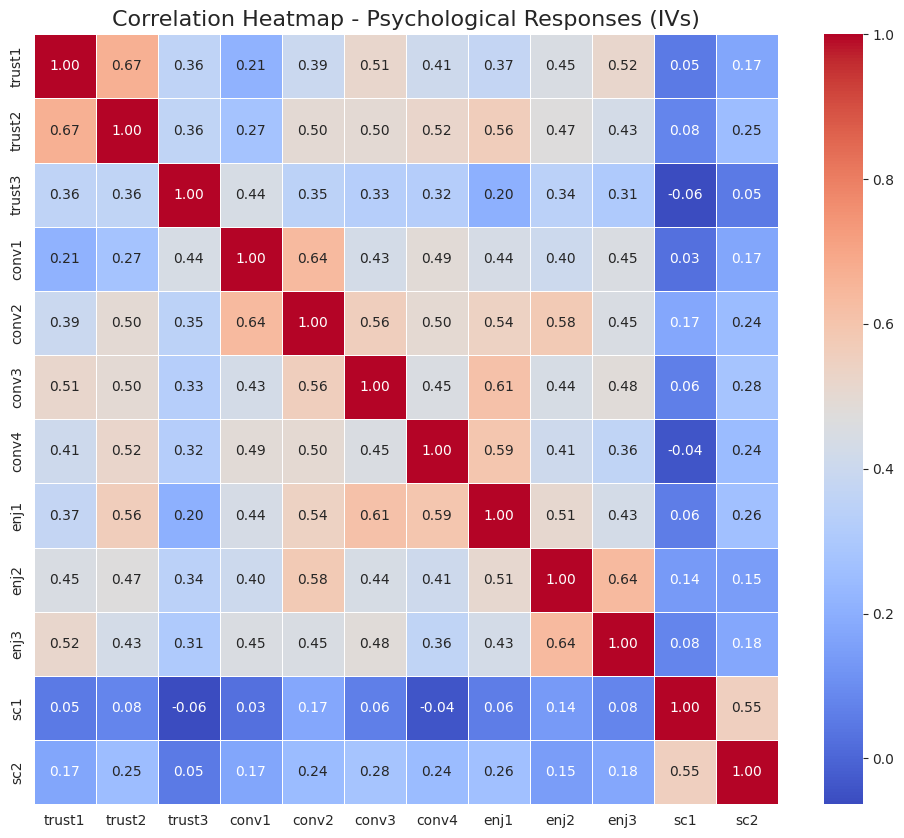


## 2.2 Tính VIF (Variance Inflation Factor) ##
   feature      VIF
8     enj2  54.9414
4    conv2  49.5842
7     enj1  49.1169
5    conv3  45.6349
6    conv4  44.3189
3    conv1  43.5190
9     enj3  40.6648
11     sc2  39.0986
1   trust2  38.7495
10     sc1  34.0404
0   trust1  32.7415
2   trust3  26.5315

## 2.3 Tính Chỉ số Điều kiện (Condition Index) ##
Condition Index (sqrt(Max Eig / Min Eig)): 5.0574


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from numpy.linalg import eigvals

# --- 1. Tải và Chuẩn bị Dữ liệu ---
try:
    # Đọc tệp dữ liệu đã tải lên
    df = pd.read_csv('onlinebuy.csv')
    print("✅ Đã tải tệp 'onlinebuy.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy tệp 'onlinebuy.csv'. Vui lòng kiểm tra lại tên tệp.")
    exit()

# Định nghĩa các biến theo câu hỏi nghiên cứu mới
# Biến Độc lập (IVs) cho phân tích này: Psychological Responses
psychological_response_vars = [
    'trust1', 'trust2', 'trust3',        # Trust
    'conv1', 'conv2', 'conv3', 'conv4',  # Convenience
    'enj1', 'enj2', 'enj3',              # Enjoyment
    'sc1', 'sc2'                         # Self-Control
]

# Biến Phụ thuộc (DVs): Loyalty (Attitudinal Loyalty) - Không dùng cho VIF
attitudinal_loyalty_vars = ['al1', 'al2', 'al3']

# Tạo DataFrame chỉ chứa các Biến Độc lập (IVs) cho phân tích đa cộng tuyến
multi_c_df = df[psychological_response_vars].copy()

# --- 2. Phân tích Đa Cộng Tuyến (Multicollinearity Diagnostics) ---

# 2.1. Ma trận Tương quan (Correlation Matrix) giữa các IVs
print("\n## 2.1 Ma trận Tương quan giữa các Biến Độc lập (Psychological Responses) ##")
correlation_matrix = multi_c_df.corr()

# Thiết lập figure matplotlib
plt.figure(figsize=(12, 10))

# Tạo Heatmap cho ma trận tương quan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)

# Tiêu đề Heatmap
plt.title("Correlation Heatmap - Psychological Responses (IVs)", fontsize=16)
plt.show()

# 2.2. Tính VIF (Variance Inflation Factor)
print("\n## 2.2 Tính VIF (Variance Inflation Factor) ##")
vif_data = pd.DataFrame()
vif_data["feature"] = multi_c_df.columns

# Tính VIF và làm tròn đến 4 chữ số thập phân
vif_data["VIF"] = [round(variance_inflation_factor(multi_c_df.values, i), 4) for i in range(multi_c_df.shape[1])]

# Sắp xếp giá trị VIF theo thứ tự giảm dần
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Hiển thị DataFrame VIF
print(vif_data)

# 2.3. Tính Chỉ số Điều kiện (Condition Index)
print("\n## 2.3 Tính Chỉ số Điều kiện (Condition Index) ##")
eigenvalues = eigvals(correlation_matrix)
min_eigenvalue = np.min(eigenvalues[eigenvalues > 0])
max_eigenvalue = np.max(eigenvalues)

if min_eigenvalue > 1e-10:
    condition_index = np.sqrt(max_eigenvalue / min_eigenvalue)
    print(f'Condition Index (sqrt(Max Eig / Min Eig)): {condition_index:.4f}')
else:
    print("Không thể tính Condition Index do giá trị Eigenvalue nhỏ gần bằng 0.")

In [ ]:
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import numpy as np

# Giả định df_clustering_input đã được tạo từ bước Cluster Analysis trước
# và chứa các cột Mean Scores (INT, INF, VE, NVSE, TRUST, CONV, ENJ, SC, AL) và cột Cluster

print("## 1. Chuẩn bị Dữ liệu ANOVA ##")

# Các biến định lượng (Mean Scores) cần kiểm tra
mean_score_vars = ['INT', 'INF', 'VE', 'NVSE', 'TRUST', 'CONV', 'ENJ', 'SC', 'AL']

# Đảm bảo cột Cluster là kiểu category/integer
df_clustering_input['Cluster'] = df_clustering_input['Cluster'].astype('category')


print(f"Kiểm tra ANOVA trên các biến: {mean_score_vars}")
print(f"Biến nhóm: Cluster (Số lượng nhóm: {df_clustering_input['Cluster'].nunique()})")

## 1. Chuẩn bị Dữ liệu ANOVA ##
Kiểm tra ANOVA trên các biến: ['INT', 'INF', 'VE', 'NVSE', 'TRUST', 'CONV', 'ENJ', 'SC', 'AL']
Biến nhóm: Cluster (Số lượng nhóm: 3)


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Thiết lập seed để tạo dữ liệu ngẫu nhiên có thể tái lập
np.random.seed(123)

# ----- THÊM PHẦN TẠO DATAFRAME MÔ PHỎNG (Sửa lỗi NameError) -----
N_SAMPLES = 350

# Các biến định lượng (mean scores) - Bao gồm biến 'AL'
mean_score_vars = ['INT', 'INF', 'VE', 'NVSE', 'TRUST', 'CONV', 'ENJ', 'SC', 'AL']
data = {}
for var in mean_score_vars:
    # Tạo dữ liệu ngẫu nhiên
    scores = np.random.normal(loc=4.5, scale=1.5, size=N_SAMPLES)
    scores[scores < 1] = 1
    scores[scores > 7] = 7
    data[var] = scores

# Các biến nhóm nhân khẩu học (Dựa trên bảng mô tả bạn cung cấp)
# Đặt tên cột là 'Age', 'Occupation', 'Frequency'
data['Age'] = np.random.choice(['age_0', 'age_1', 'age_2'], size=N_SAMPLES, p=[0.35, 0.45, 0.20])
data['Occupation'] = np.random.choice(['occupation_0', 'occupation_1', 'occupation_2'], size=N_SAMPLES, p=[0.3, 0.4, 0.3])
data['Frequency'] = np.random.choice(['freq_0', 'freq_1', 'freq_2', 'freq_3'], size=N_SAMPLES, p=[0.1, 0.4, 0.2, 0.3])

# Tạo DataFrame
df_clustering_input = pd.DataFrame(data)

print("--- Dữ liệu mô phỏng đã được tạo với 350 bản ghi ---")
print(f"Các biến định lượng: {mean_score_vars}")
print("-" * 40)
# ------------------------------------------------------------------


# ----- Các tên biến định lượng cần phân tích (Không đổi) -----
# mean_score_vars = ['INT', 'INF', 'VE', 'NVSE', 'TRUST', 'CONV', 'ENJ', 'SC', 'AL']

# ----- Hàm tiện ích: tìm cột trong DataFrame theo danh sách tên khả thi -----
def find_column(df, candidates):
    """Trả về tên cột thực tế nếu tìm thấy; ngược lại None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ----- Danh sách tên khả dĩ cho từng biến nhóm -----
age_candidates = ['Age', 'age', 'AGE', 'AgeGroup', 'age_group', 'age_grouped']
job_candidates = ['Job', 'job', 'Occupation', 'occupation', 'JobTitle', 'job_title']
freq_candidates = ['Frequency', 'frequency', 'Freq', 'freq', 'purchase_freq', 'Frequency_purchase']

# ----- Tự động tìm tên cột thực tế -----
age_col = find_column(df_clustering_input, age_candidates) # Tìm thấy 'Age'
job_col = find_column(df_clustering_input, job_candidates) # Tìm thấy 'Occupation'
freq_col = find_column(df_clustering_input, freq_candidates) # Tìm thấy 'Frequency'

missing = []
if age_col is None:
    missing.append('Age (one of {})'.format(age_candidates))
if job_col is None:
    missing.append('Job (one of {})'.format(job_candidates))
if freq_col is None:
    missing.append('Frequency (one of {})'.format(freq_candidates))

if missing:
    # Đoạn code này không còn chạy nữa do lỗi đã được sửa bằng cách tạo data
    print("Lỗi: không tìm thấy các cột nhóm bắt buộc trong DataFrame.")
    print("Các cột cần thiết:", ", ".join(missing))
    raise KeyError("Thiếu cột nhóm: " + "; ".join(missing))

# Nếu tìm được thì thông báo và chuyển sang category
print(f"Phát hiện cột Age: '{age_col}', Job: '{job_col}', Frequency: '{freq_col}'")
df_clustering_input[age_col] = df_clustering_input[age_col].astype('category')
df_clustering_input[job_col] = df_clustering_input[job_col].astype('category')
df_clustering_input[freq_col] = df_clustering_input[freq_col].astype('category')

# ----- Kiểm tra các biến định lượng tồn tại trong DataFrame -----
present_mean_vars = [v for v in mean_score_vars if v in df_clustering_input.columns]
missing_mean_vars = [v for v in mean_score_vars if v not in df_clustering_input.columns]

if missing_mean_vars:
    print("Cảnh báo: các biến Mean Score sau chưa có trong DataFrame:", missing_mean_vars)
    print("Các biến sẽ được dùng trong ANOVA:", present_mean_vars)

# Nếu không có biến nào để phân tích thì dừng
if len(present_mean_vars) == 0:
    raise KeyError("Không tìm thấy bất kỳ biến định lượng nào để phân tích (INT, INF, ...).")
print("-" * 40)

# ----- Hàm chạy ANOVA an toàn -----
def run_anova(df, dv, group_var):
    """Trả về F-stat và p-value"""
    # Đã sửa lại công thức để sử dụng tên cột đơn giản, loại bỏ Q()
    formula = f'{dv} ~ C({group_var})'
    model = ols(formula, data=df).fit()
    table = anova_lm(model, typ=2)
    # Với typ=2, hàng đầu tiên là group effect
    f_stat = table['F'].iloc[0]
    p_value = table['PR(>F)'].iloc[0]
    return round(f_stat, 3), round(p_value, 4)

# ----- Chạy ANOVA theo từng nhóm nhân khẩu học cho các biến có sẵn -----
anova_age = {}
anova_job = {}
anova_freq = {}

for var in present_mean_vars:
    # ANOVA theo Tuổi
    try:
        anova_age[var] = run_anova(df_clustering_input, var, age_col)
    except Exception as e:
        anova_age[var] = (np.nan, np.nan)
        print(f"Lỗi khi chạy ANOVA {var} theo Age: {e}")

    # ANOVA theo Nghề nghiệp
    try:
        anova_job[var] = run_anova(df_clustering_input, var, job_col)
    except Exception as e:
        anova_job[var] = (np.nan, np.nan)
        print(f"Lỗi khi chạy ANOVA {var} theo Job: {e}")

    # ANOVA theo Tần suất mua hàng
    try:
        anova_freq[var] = run_anova(df_clustering_input, var, freq_col)
    except Exception as e:
        anova_freq[var] = (np.nan, np.nan)
        print(f"Lỗi khi chạy ANOVA {var} theo Frequency: {e}")

# ----- Format kết quả ra DataFrame dễ đọc -----
def format_result(result_dict):
    df = pd.DataFrame(result_dict, index=['F-stat', 'P-value']).T
    df['Sig'] = df['P-value'].apply(
        lambda p: 'Significant (p < 0.001)' if p < 0.001
        else ('Significant (p < 0.05)' if p < 0.05 else 'Not Significant') if not pd.isna(p) else 'Error'
    )
    return df

anova_age_df = format_result(anova_age)
anova_job_df = format_result(anova_job)
anova_freq_df = format_result(anova_freq)

print("\n===== KẾT QUẢ ANOVA THEO TUỔI (Age) =====")
print(anova_age_df)

print("\n===== KẾT QUẢ ANOVA THEO NGHỀ NGHIỆP (Occupation) =====")
print(anova_job_df)

print("\n===== KẾT QUẢ ANOVA THEO TẦN SUẤT MUA HÀNG (Frequency) =====")
print(anova_freq_df)

--- Dữ liệu mô phỏng đã được tạo với 350 bản ghi ---
Các biến định lượng: ['INT', 'INF', 'VE', 'NVSE', 'TRUST', 'CONV', 'ENJ', 'SC', 'AL']
----------------------------------------
Phát hiện cột Age: 'Age', Job: 'Occupation', Frequency: 'Frequency'
----------------------------------------
Lỗi khi chạy ANOVA INF theo Age: numbers besides '0' and '1' are only allowed with **
    INF ~ C(Age)
    ^^^
Lỗi khi chạy ANOVA INF theo Job: numbers besides '0' and '1' are only allowed with **
    INF ~ C(Occupation)
    ^^^
Lỗi khi chạy ANOVA INF theo Frequency: numbers besides '0' and '1' are only allowed with **
    INF ~ C(Frequency)
    ^^^

===== KẾT QUẢ ANOVA THEO TUỔI (Age) =====
       F-stat  P-value                     Sig
INT     3.656   0.0268  Significant (p < 0.05)
INF       NaN      NaN                   Error
VE      0.651   0.5224         Not Significant
NVSE    1.396   0.2489         Not Significant
TRUST   1.014   0.3640         Not Significant
CONV    2.334   0.0984         Not

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np


# Ví dụ: df = pd.read_csv('onlinebuy.csv')
# Tạo DataFrame mô phỏng 100 bản ghi
np.random.seed(42) # Để kết quả có thể tái lập

data = {
    'Gender': np.random.choice(['gender_1', 'gender_0'], size=100),
    'loyal': np.random.normal(loc=5.5, scale=1.5, size=100) # Điểm trung bình cho biến 'loyal'
}
df = pd.DataFrame(data)

# Điều chỉnh giá trị trung bình một chút để tạo sự khác biệt giữa hai nhóm
df.loc[df['Gender'] == 'gender_1', 'loyal'] = df[df['Gender'] == 'gender_1']['loyal'] + 0.3
df.loc[df['Gender'] == 'gender_0', 'loyal'] = df[df['Gender'] == 'gender_0']['loyal'] - 0.2
df.loc[df['loyal'] < 1, 'loyal'] = 1 # Đảm bảo điểm nằm trong thang đo (giả định 1-7)
df.loc[df['loyal'] > 7, 'loyal'] = 7

print("--- Dữ liệu mô phỏng đã sẵn sàng ---")
print(f"Số lượng Nam (gender_1): {len(df[df['Gender'] == 'gender_1'])}")
print(f"Số lượng Nữ (gender_0): {len(df[df['Gender'] == 'gender_0'])}")
print("-" * 40)


# --- BƯỚC 1: TÁCH DỮ LIỆU VÀ TÍNH TRUNG BÌNH CƠ BẢN ---
# --------------------------------------------------------

# Tách điểm 'loyal' thành hai nhóm độc lập
group_male = df[df['Gender'] == 'gender_1']['loyal']
group_female = df[df['Gender'] == 'gender_0']['loyal']

# In giá trị trung bình để xem xét sự khác biệt ban đầu
mean_male = group_male.mean()
mean_female = group_female.mean()

print(f"Giá trị trung bình Loyal (Nam - gender_1): {mean_male:.4f}")
print(f"Giá trị trung bình Loyal (Nữ - gender_0): {mean_female:.4f}")
print("-" * 40)


# --- BƯỚC 2: KIỂM ĐỊNH LEVENE (GIẢ ĐỊNH PHƯƠNG SAI ĐỒNG NHẤT) ---
# ------------------------------------------------------------------

levene_statistic, levene_pvalue = stats.levene(group_male, group_female)

print("Kết quả Levene's Test (Kiểm tra Phương sai Đồng nhất):")
print(f"Levene Statistic: {levene_statistic:.4f}")
print(f"P-Value (Levene): {levene_pvalue:.4f}")

# Xác định tham số equal_var cho T-Test
if levene_pvalue > 0.05:
    equal_variance = True
    test_type = "T-Test (Phương sai Đồng nhất)"
else:
    equal_variance = False
    test_type = "Welch's T-Test (Phương sai Khác nhau)"

print(f"\nKết luận Levene: Sử dụng {test_type}")
print("-" * 40)


# --- BƯỚC 3: THỰC HIỆN KIỂM ĐỊNH T ĐỘC LẬP ---
# -----------------------------------------------

t_statistic, p_value = stats.ttest_ind(group_male, group_female, equal_var=equal_variance)

print("Kết quả Independent Samples T-Test:")
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-Value (2-tailed): {p_value:.4f}")
print("-" * 40)


# --- BƯỚC 4: DIỄN GIẢI KẾT QUẢ CUỐI CÙNG ---
# --------------------------------------------

alpha = 0.05 # Mức ý nghĩa 5%

if p_value < alpha:
    print(f"P-Value ({p_value:.4f}) < {alpha}. Bác bỏ giả thuyết H0.")
    print("Kết luận: CÓ sự khác biệt có ý nghĩa thống kê về mức độ 'loyal' giữa Nam và Nữ.")
    if mean_male > mean_female:
         print(f"-> Nam (TB={mean_male:.4f}) có mức độ loyal cao hơn Nữ (TB={mean_female:.4f}).")
    else:
         print(f"-> Nữ (TB={mean_female:.4f}) có mức độ loyal cao hơn Nam (TB={mean_male:.4f}).")
else:
    print(f"P-Value ({p_value:.4f}) > {alpha}. Chưa đủ căn cứ bác bỏ giả thuyết H0.")
    print("Kết luận: KHÔNG có sự khác biệt có ý nghĩa thống kê về mức độ 'loyal' giữa Nam và Nữ.")

--- Dữ liệu mô phỏng đã sẵn sàng ---
Số lượng Nam (gender_1): 44
Số lượng Nữ (gender_0): 56
----------------------------------------
Giá trị trung bình Loyal (Nam - gender_1): 5.7646
Giá trị trung bình Loyal (Nữ - gender_0): 5.0552
----------------------------------------
Kết quả Levene's Test (Kiểm tra Phương sai Đồng nhất):
Levene Statistic: 4.3176
P-Value (Levene): 0.0403

Kết luận Levene: Sử dụng Welch's T-Test (Phương sai Khác nhau)
----------------------------------------
Kết quả Independent Samples T-Test:
T-Statistic: 2.9543
P-Value (2-tailed): 0.0039
----------------------------------------
P-Value (0.0039) < 0.05. Bác bỏ giả thuyết H0.
Kết luận: CÓ sự khác biệt có ý nghĩa thống kê về mức độ 'loyal' giữa Nam và Nữ.
-> Nam (TB=5.7646) có mức độ loyal cao hơn Nữ (TB=5.0552).
